<a href="https://colab.research.google.com/github/taru30174/future_interns/blob/main/AI_powered_salesforecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-410419176.py:6: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train  = pd.read_csv("train.csv", parse_dates=['Date'])
INFO:prophet:n_changepoints greater than number of observations. Using 23.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


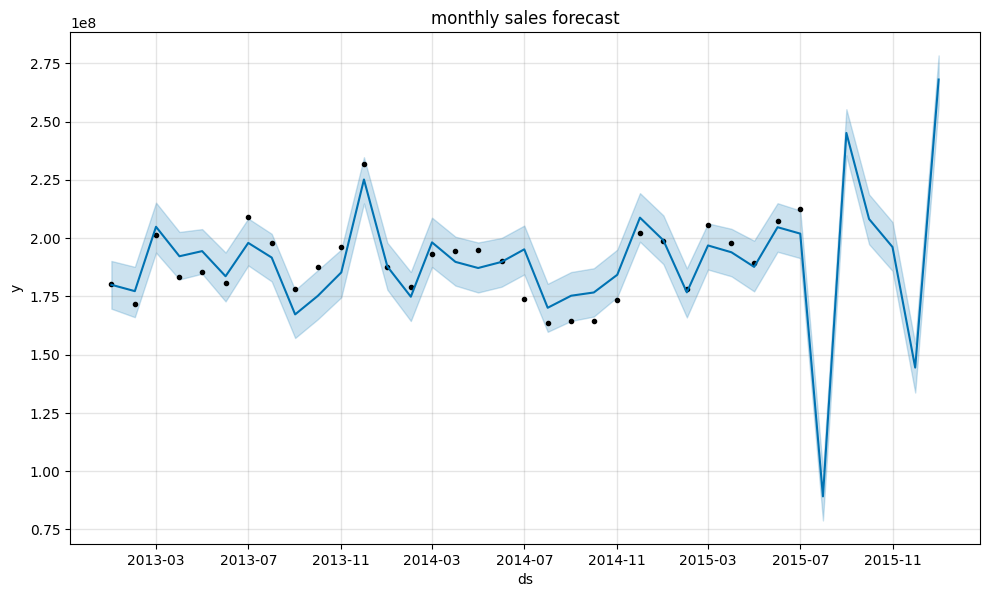

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import prophet as Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
train  = pd.read_csv("train.csv", parse_dates=['Date'])
test = pd.read_csv("test.csv", parse_dates=['Date'])
store = pd.read_csv("store.csv")
train = pd.merge(train , store, on='Store', how = "left")
test = pd.merge(test , store, on='Store', how = "left")
train = train[train['Open'] == 1]
train = train[train['Sales'] > 0]
train['Month'] = train['Date'].dt.to_period('M')
monthly_sales = (train.groupby('Month')['Sales'].sum().reset_index())
monthly_sales['Month'] = monthly_sales["Month"].dt.to_timestamp()
monthly_sales.head()
prophet_df = monthly_sales.rename(columns={'Month': 'ds', 'Sales': 'y'})
prophet_df.head()
model = Prophet.Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(prophet_df)
future = model.make_future_dataframe(periods=6, freq='M')
forecast = model.predict(future)
forecast.tail()
fig = model.plot(forecast)
plt.title("monthly sales forecast")
plt.show()
forecast_out = forecast[["ds","yhat","yhat_lower","yhat_upper"]]
forecast_out.to_csv("sales_forecast_powerbi.csv", index = False)
forecast_out.head()
files.download('sales_forecast_powerbi.csv')